# Object Detection Tasks
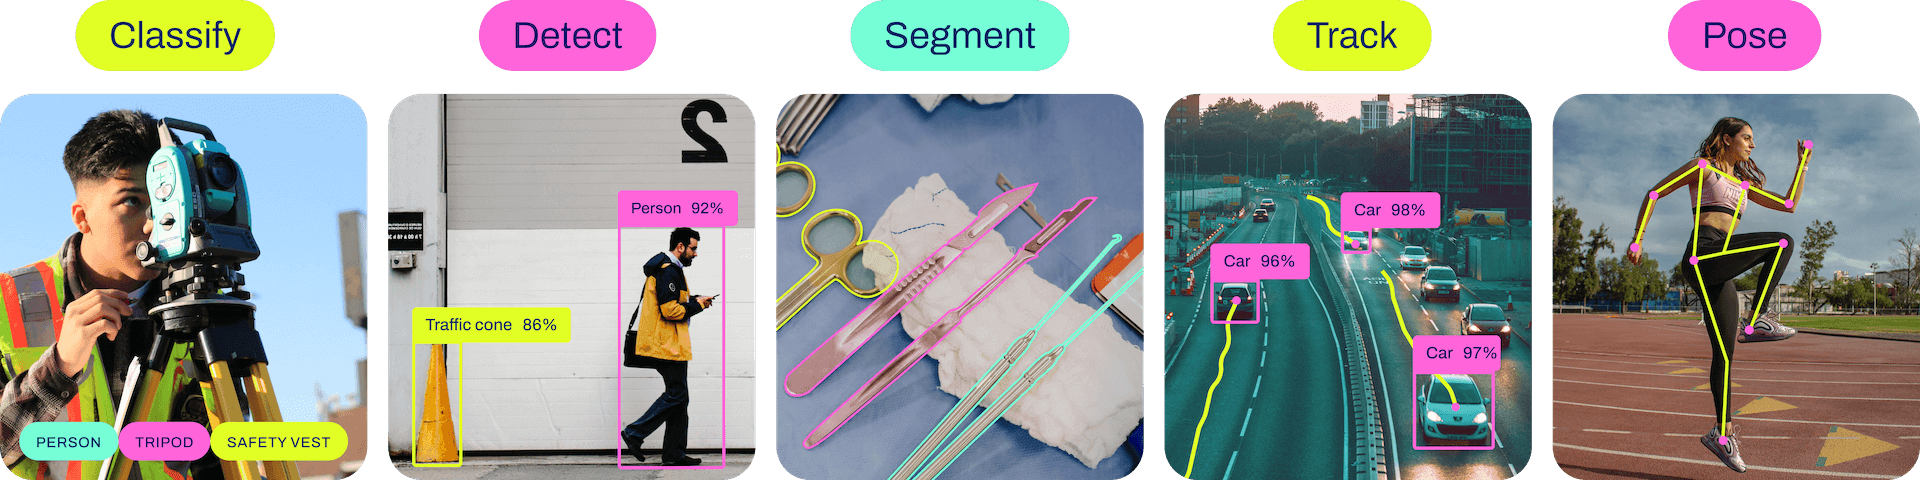

# Haar Cascades

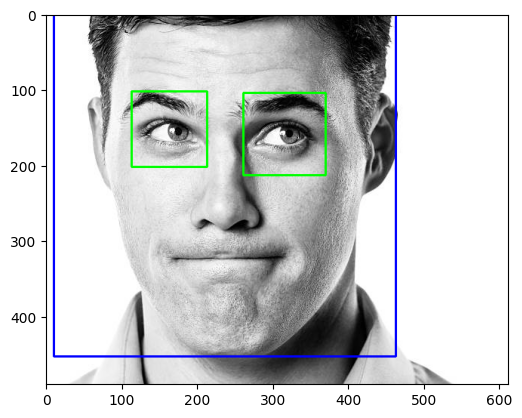

In [10]:
import numpy as np
import cv2
#from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

img = cv2.imread("istockphoto-183344835-612x612.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.8, 1)


for (x,y,w,h) in faces:
    img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.09)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.show()

# Playing with Yolo v8

### 0. Setup

In [13]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.22  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 7 7435HS)
Setup complete  (16 CPUs, 23.7 GB RAM, 28.4/97.7 GB disk)


### 1. Predict

YOLOv8 may be used directly in the Command Line Interface (CLI) with a `yolo` command for a variety of tasks and modes and accepts additional arguments, i.e. `imgsz=640`. See a full list of available `yolo` [arguments](https://docs.ultralytics.com/usage/cfg/) and other details in the [YOLOv8 Predict Docs](https://docs.ultralytics.com/modes/train/).


In [11]:
!yolo --help

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\akank\AppData\Roaming\Python\Python312\Scripts\yolo.exe\__main__.py", line 2, in <module>
ModuleNotFoundError: No module named 'ultralytics'


In [14]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/zidane.jpg'


Ultralytics 8.4.22  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 7 7435HS)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


image 1/1 e:\Machine Learning\21 Projects in 21 days\zidane.jpg: 384x640 2 persons, 1 tie, 215.7ms
Speed: 65.3ms preprocess, 215.7ms inference, 16.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to E:\Machine Learning\runs\detect\predict
 Learn more at https://docs.ultralytics.com/modes/predict


In [20]:
import requests

response = requests.get('https://ultralytics.com/images/zidane.jpg')
with open('zidane.jpg', 'wb') as f:
    f.write(response.content)

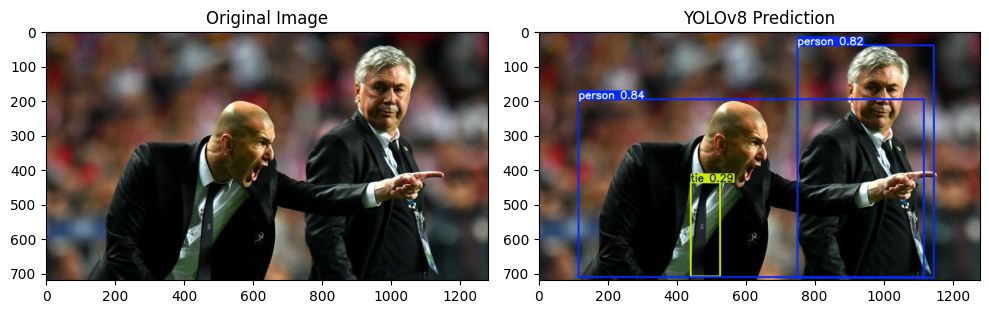

In [21]:
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def load_or_predict_image(filename, model_name="yolov8n.pt"):
    matches = sorted(
        Path("runs/detect").glob(f"predict*/{filename}"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if matches:
        return cv2.imread(str(matches[0]))

    model = YOLO(model_name)
    result = model(filename, verbose=False)[0]
    return result.plot()

img1 = cv2.imread("zidane.jpg")
img2 = load_or_predict_image("zidane.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the images in the subplots
axes[0].imshow(img1_rgb)
axes[0].set_title("Original Image")
#axes[0].axis('off') # Hide axes

axes[1].imshow(img2_rgb)
axes[1].set_title("YOLOv8 Prediction")
#axes[1].axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

# YOLO26

In [22]:
!yolo predict model=yolov8n.pt source='https://ultralytics.com/images/bus.jpg'

Ultralytics 8.4.22  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 7 7435HS)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


image 1/1 e:\Machine Learning\21 Projects in 21 days\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 138.5ms
Speed: 4.7ms preprocess, 138.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to E:\Machine Learning\runs\detect\predict2
 Learn more at https://docs.ultralytics.com/modes/predict


In [23]:
import requests

response = requests.get('https://ultralytics.com/images/bus.jpg')
with open('bus.jpg', 'wb') as f:
    f.write(response.content)

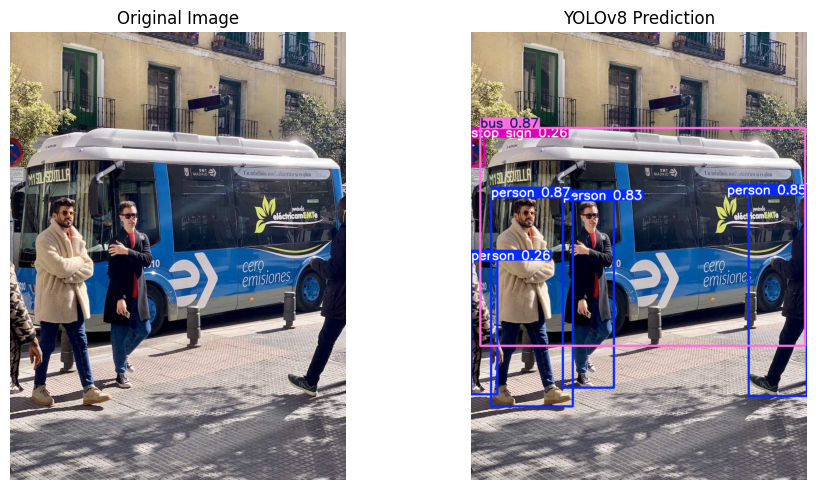

In [24]:
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def load_or_predict_image(filename, model_name="yolov8n.pt"):
    matches = sorted(
        Path("runs/detect").glob(f"predict*/{filename}"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if matches:
        return cv2.imread(str(matches[0]))

    model = YOLO(model_name)
    result = model(filename, verbose=False)[0]
    return result.plot()

img1 = cv2.imread("bus.jpg")
img2 = load_or_predict_image("bus.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the images in the subplots
axes[0].imshow(img1_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off') # Hide axes

axes[1].imshow(img2_rgb)
axes[1].set_title("YOLOv8 Prediction")
axes[1].axis('off') # Hide axes

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

In [25]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo26n.pt")  # load an official model

# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 e:\Machine Learning\21 Projects in 21 days\bus.jpg: 640x480 4 persons, 1 bus, 90.3ms
Speed: 3.0ms preprocess, 90.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


## Processing a video

In [26]:
! yolo predict model=yolo26n-seg.pt source='https://youtube.com/shorts/Z_5sREVaJDc?si=aaZZOl_Ik39pstuw' imgsz=320


Ultralytics 8.4.22  Python-3.13.12 torch-2.10.0+cpu CPU (AMD Ryzen 7 7435HS)
YOLO26n-seg summary (fused): 139 layers, 2,722,980 parameters, 0 gradients, 9.1 GFLOPs

requirements: Ultralytics requirement ['pytubefix>=6.5.2'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.9 MB/s  0:00:00
   ---------------------------------------- 0.0/41.2 MB ? eta -:--:--
    --------------------------------------- 0.5/41.2 MB 2.8 MB/s eta 0:00:15
   - -------------------------------------- 1.3/41.2 MB 3.9 MB/s eta 0:00:11
   -- ------------------------------------- 2.6/41.2 MB 4.6 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/41.2 MB 5.0 MB/s eta 0:00:08
   ---- ----------------------------------- 5.0/41.2 MB 5.1 MB/s eta 0:00: